# Radiosonde Profile Diagnostics

This notebook uses [PyGSI](https://github.com/NOAA-EMC/PyGSI) to load GSI conventional
diagnostic netCDF4 files and plot vertical profiles of radiosonde observations and their
departures from the model background (O-F) and analysis (O-A) as a function of pressure.

Variables plotted:
- **Temperature** (K)
- **Specific humidity** (g/kg)
- **U-wind** and **V-wind** (m/s)

For each variable the following quantities are shown:
- Observation (Obs)
- Observation minus background / first-guess (O-F)
- Observation minus analysis (O-A)
- Model background (H(x))

---

## Setup

Install dependencies once (skip if already installed):

```bash
pip install -r ../requirements.txt
```

## 1. Configuration

Edit the cells below to select the cycle date, station ID, and the base URL
from which the GSI diagnostic files will be downloaded.

In [2]:
import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------------------------------------------------------------
# USER CONFIGURATION — modify these values before running the notebook
# ---------------------------------------------------------------------------

# Cycle date-time in YYYYMMDDHH format
CYCLE_DATE: str = "2026062900"

# Radiosonde station ID to inspect (WMO or BUFR identifier string).
# Call `list_stationids()` in a later cell to discover IDs in the file.
STATION_ID: str = "72403"  # example: Sterling, VA (WMO 72403)

# Base URL where the GSI diagnostic files are hosted.
# Falls back to the DIAG_BASE_URL environment variable when left empty.
BASE_URL: str = os.environ.get("DIAG_BASE_URL", "http://www.emc.ncep.noaa.gov/users/cmartin/cadre")

# Local directory for downloaded files
DATA_DIR: Path = Path("../data")

# GSI rawinsonde observation type IDs
RAOB_OBSID_T_Q: list[int] = [120]   # Rawinsonde temperature and humidity
RAOB_OBSID_UV: list[int]  = [220]   # Rawinsonde wind

# ---------------------------------------------------------------------------
print(f"Cycle:      {CYCLE_DATE}")
print(f"Station:    {STATION_ID}")
print(f"Data dir:   {DATA_DIR.resolve()}")
print(f"Base URL:   {BASE_URL or '(not set)'}")

Cycle:      2026062900
Station:    72403
Data dir:   /work/noaa/da/cmartin/cadre/cadre-sonde/data
Base URL:   http://www.emc.ncep.noaa.gov/users/cmartin/cadre


In [2]:
# Make the scripts directory importable from inside the notebooks folder
sys.path.insert(0, str(Path("../scripts").resolve()))

from download_diag import download_diag_files

if not BASE_URL:
    print(
        "WARNING: BASE_URL is not set.\n"
        "Set the BASE_URL variable (cell 1) or the DIAG_BASE_URL "
        "environment variable to enable automatic downloads.\n"
        "Continuing with files already in DATA_DIR (if present)."
    )
    diag_paths: list = []
else:
    diag_paths = download_diag_files(
        date=CYCLE_DATE,
        base_url=BASE_URL,
        outdir=DATA_DIR,
        skip_existing=True,
    )
    print(f"\nDownloaded / found {len(diag_paths)} file(s).")

[download] http://www.emc.ncep.noaa.gov/users/cmartin/cadre/gdas.t00z.cnvstat -> ../data/gdas.t00z.cnvstat

Downloaded / found 0 file(s).


[error]    gdas.t00z.cnvstat: <urlopen error Network error downloading http://www.emc.ncep.noaa.gov/users/cmartin/cadre/gdas.t00z.cnvstat: [Errno 110] Connection timed out>


## 3. Load Diagnostic Files with PyGSI

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pyGSI.diags import Conventional


def _diag_path(variable: str, ftype: str) -> Path:
    """Return the expected local path for a GSI diagnostic file.

    Parameters
    ----------
    variable:
        Variable code: ``'t'``, ``'q'``, ``'uv'``, or ``'ps'``.
    ftype:
        File type: ``'ges'`` (first guess) or ``'anl'`` (analysis).

    Returns
    -------
    pathlib.Path
        Absolute path under ``DATA_DIR``.

    Examples
    --------
    >>> _diag_path('t', 'ges')  # doctest: +SKIP
    PosixPath('../data/diag_conv_t_ges.2020092000.nc4')
    """
    fname = f"diag_conv_{variable}_{ftype}.{CYCLE_DATE}.nc4"
    return DATA_DIR / fname


def load_conv(variable: str, ftype: str) -> "Conventional | None":
    """Load a Conventional diagnostic object, returning None if missing.

    Parameters
    ----------
    variable:
        Variable code: ``'t'``, ``'q'``, ``'uv'``, or ``'ps'``.
    ftype:
        File type: ``'ges'`` (first guess) or ``'anl'`` (analysis).

    Returns
    -------
    pyGSI.diags.Conventional or None
        Loaded diagnostic object, or *None* when the file does not
        exist locally.

    Examples
    --------
    >>> diag = load_conv('t', 'ges')  # doctest: +SKIP
    """
    path = _diag_path(variable, ftype)
    if not path.exists():
        print(f"[missing] {path}")
        return None
    print(f"[ok]      {path.name}")
    return Conventional(str(path))


# Load first-guess (ges) and analysis (anl) files for T, q, uv
diag_t_ges  = load_conv("t",  "ges")
diag_t_anl  = load_conv("t",  "anl")
diag_q_ges  = load_conv("q",  "ges")
diag_q_anl  = load_conv("q",  "anl")
diag_uv_ges = load_conv("uv", "ges")
diag_uv_anl = load_conv("uv", "anl")

[ok]      diag_conv_t_ges.2026062900.nc4
[ok]      diag_conv_t_anl.2026062900.nc4
[ok]      diag_conv_q_ges.2026062900.nc4
[ok]      diag_conv_q_anl.2026062900.nc4
[ok]      diag_conv_uv_ges.2026062900.nc4
[ok]      diag_conv_uv_anl.2026062900.nc4


## 4. Explore Available Station IDs

Run the cell below to print all station IDs present in the temperature diagnostic
file and verify that `STATION_ID` exists in this cycle.

In [5]:
if diag_t_ges is not None:
    diag_t_ges.list_stationids()
    diag_t_ges.list_obsids()
else:
    print("Temperature ges file not loaded; cannot list station IDs.")

Station IDs in this diagnostic file include:
00005112, 00005124, 00005131, 00005178, 00MWU3BA, 00SYNGBA, 01001, 01002, 01003, 01006, 01007, 01008, 01009, 01010, 01011, 01013, 01016, 01017, 01020, 01023, 01025, 01026, 01028, 01033, 01037, 01039, 01044, 01046, 01049, 01052, 01055, 01058, 01059, 01062, 01064, 01065, 01068, 01074, 01076, 01078, 01082, 01083, 01086, 01088, 01089, 01092, 01098, 01099, 01102, 01107, 01108, 01112, 01115, 01116, 01121, 01122, 01132, 01135, 01139, 01141, 01151, 01152, 01156, 01158, 01160, 01161, 01162, 01169, 01180, 01183, 01198, 01199, 01203, 01205, 01209, 01210, 01212, 01217, 01218, 01223, 01225, 01228, 01232, 01237, 01238, 01240, 01241, 01245, 01257, 01259, 01265, 01271, 01273, 01277, 01281, 01282, 01288, 01290, 01293, 01304, 01307, 01310, 01311, 01317, 01320, 01321, 01323, 01327, 01329, 01337, 01338, 01340, 01347, 01350, 01355, 01357, 01358, 01359, 01361, 01362, 01363, 01364, 01366, 01367, 01368, 01370, 01373, 01375, 01378, 01383, 01385, 01389, 01392, 01393,

## 5. Extract Station Profile

Filter each diagnostic object to the selected `STATION_ID` and radiosonde
observation type IDs, then reset the multi-level index so `Pressure` becomes
a plain column for sorting and plotting.

In [6]:
def get_station_profile(
    diag: Conventional | None,
    obsid: list[int],
    station_id: str,
) -> pd.DataFrame:
    """Extract and sort one station's data from a Conventional diag object.

    Parameters
    ----------
    diag:
        A loaded :class:`~pyGSI.diags.Conventional` object, or *None*
        if the file was not available.
    obsid:
        List of BUFR observation type IDs to keep (e.g. ``[120]``).
    station_id:
        WMO / BUFR station identifier string.

    Returns
    -------
    pandas.DataFrame
        DataFrame sorted by descending pressure (surface to stratosphere)
        with the multi-index reset to plain columns.  Returns an empty
        DataFrame if *diag* is *None* or the station has no data.
    """
    if diag is None:
        return pd.DataFrame()

    df = diag.get_data(obsid=obsid, station_id=[station_id])
    if isinstance(df, dict):
        # analysis_use=True returns a dict — merge all subsets
        df = pd.concat(df.values())

    if df.empty:
        return pd.DataFrame()

    df = df.reset_index()
    # Sort surface → top (descending pressure)
    df = df.sort_values("Pressure", ascending=False).reset_index(drop=True)
    return df


# Temperature
df_t_ges  = get_station_profile(diag_t_ges,  RAOB_OBSID_T_Q, STATION_ID)
df_t_anl  = get_station_profile(diag_t_anl,  RAOB_OBSID_T_Q, STATION_ID)

# Specific humidity
df_q_ges  = get_station_profile(diag_q_ges,  RAOB_OBSID_T_Q, STATION_ID)
df_q_anl  = get_station_profile(diag_q_anl,  RAOB_OBSID_T_Q, STATION_ID)

# Wind
df_uv_ges = get_station_profile(diag_uv_ges, RAOB_OBSID_UV,  STATION_ID)
df_uv_anl = get_station_profile(diag_uv_anl, RAOB_OBSID_UV,  STATION_ID)

for label, df in [
    ("T  ges", df_t_ges),  ("T  anl", df_t_anl),
    ("q  ges", df_q_ges),  ("q  anl", df_q_anl),
    ("uv ges", df_uv_ges), ("uv anl", df_uv_anl),
]:
    print(f"Station {STATION_ID}  {label}: {len(df):>4d} levels")

Station 72403  T  ges:  255 levels
Station 72403  T  anl:  255 levels
Station 72403  q  ges:  255 levels
Station 72403  q  anl:  255 levels
Station 72403  uv ges:  255 levels
Station 72403  uv anl:  255 levels


## 6. Plot Radiosonde Profiles

Four-panel figure for each variable (temperature, specific humidity, U-wind, V-wind):

| Panel | Contents |
|-------|----------|
| Left | Observed value and model background H(x) vs pressure |
| Right | O-F (first guess departure) and O-A (analysis departure) vs pressure |

In [7]:
# ── Shared plotting helpers ────────────────────────────────────────────────

PRES_TICKS: list[float] = [1000, 850, 700, 500, 400, 300, 250, 200, 150, 100, 50, 10]
PRES_MIN: float = 10.0
PRES_MAX: float = 1050.0


def _style_pressure_axis(ax: plt.Axes) -> None:
    """Apply logarithmic pressure axis styling to *ax* (y-axis)."""
    ax.set_yscale("log")
    ax.set_ylim(PRES_MAX, PRES_MIN)
    ax.set_yticks(PRES_TICKS)
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.7)


def _add_zero_line(ax: plt.Axes) -> None:
    """Draw a dashed vertical zero line."""
    ax.axvline(0.0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)


def _annotate_stats(
    ax: plt.Axes,
    values: np.ndarray,
    label: str,
    color: str,
) -> None:
    """Add N / mean / std annotation inside the axes."""
    if len(values) == 0:
        return
    n    = len(values)
    mean = float(np.nanmean(values))
    std  = float(np.nanstd(values))
    ax.text(
        0.97, 0.02,
        f"{label}: N={n}  μ={mean:+.3f}  σ={std:.3f}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=7, color=color,
    )


def plot_scalar_profile(
    pressure_ges: np.ndarray,
    obs_ges: np.ndarray,
    hofx_ges: np.ndarray,
    omf_ges: np.ndarray,
    pressure_anl: np.ndarray,
    oma_anl: np.ndarray,
    var_label: str,
    unit: str,
    station_id: str,
    cycle_date: str,
) -> plt.Figure:
    """Two-panel profile figure for a scalar variable (T or q).

    Parameters
    ----------
    pressure_ges:
        Pressure levels (hPa) from the ges file.
    obs_ges:
        Observed values at each ges pressure level.
    hofx_ges:
        Model background equivalent H(x) at each ges pressure level.
    omf_ges:
        Observation minus first-guess (O-F) at each ges pressure level.
    pressure_anl:
        Pressure levels (hPa) from the anl file.
    oma_anl:
        Observation minus analysis (O-A) at each anl pressure level.
    var_label:
        Short variable name for titles (e.g. ``'Temperature'``).
    unit:
        Physical unit string (e.g. ``'K'``).
    station_id:
        Station identifier for the figure title.
    cycle_date:
        Cycle date-time string for the figure title.

    Returns
    -------
    matplotlib.figure.Figure
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 7), sharey=True)
    fig.suptitle(
        f"Radiosonde {var_label} — Station {station_id}  ({cycle_date} UTC)",
        fontsize=12, fontweight="bold",
    )

    # Left panel — observations and background
    ax_obs = axes[0]
    if len(obs_ges) > 0:
        ax_obs.plot(
            obs_ges, pressure_ges,
            color="royalblue", linewidth=1.5, marker="o", markersize=3,
            label="Obs",
        )
    if len(hofx_ges) > 0:
        ax_obs.plot(
            hofx_ges, pressure_ges,
            color="darkorange", linewidth=1.5, linestyle="--", marker="s", markersize=3,
            label="Background H(x)",
        )
    ax_obs.set_xlabel(f"{var_label} ({unit})", fontsize=10)
    ax_obs.set_ylabel("Pressure (hPa)", fontsize=10)
    ax_obs.set_title("Observation & Background")
    ax_obs.legend(fontsize=9)
    _style_pressure_axis(ax_obs)

    # Right panel — departures (O-F and O-A)
    ax_dep = axes[1]
    if len(omf_ges) > 0:
        ax_dep.plot(
            omf_ges, pressure_ges,
            color="crimson", linewidth=1.5, marker="o", markersize=3,
            label="O-F (ges departure)",
        )
        _annotate_stats(ax_dep, omf_ges, "O-F", "crimson")
    if len(oma_anl) > 0:
        ax_dep.plot(
            oma_anl, pressure_anl,
            color="seagreen", linewidth=1.5, linestyle="--", marker="s", markersize=3,
            label="O-A (anl departure)",
        )
    _add_zero_line(ax_dep)
    ax_dep.set_xlabel(f"Departure ({unit})", fontsize=10)
    ax_dep.set_title("Departures (O-F and O-A)")
    ax_dep.legend(fontsize=9)
    _style_pressure_axis(ax_dep)

    fig.tight_layout()
    return fig


def plot_wind_profile(
    component: str,
    pressure_ges: np.ndarray,
    obs_ges: np.ndarray,
    hofx_ges: np.ndarray,
    omf_ges: np.ndarray,
    pressure_anl: np.ndarray,
    oma_anl: np.ndarray,
    station_id: str,
    cycle_date: str,
) -> plt.Figure:
    """Two-panel profile figure for one wind component (U or V).

    Parameters
    ----------
    component:
        Wind component label (``'U'`` or ``'V'``).
    pressure_ges, obs_ges, hofx_ges, omf_ges:
        See :func:`plot_scalar_profile`.
    pressure_anl, oma_anl:
        See :func:`plot_scalar_profile`.
    station_id:
        Station identifier.
    cycle_date:
        Cycle date-time string.

    Returns
    -------
    matplotlib.figure.Figure
    """
    return plot_scalar_profile(
        pressure_ges=pressure_ges,
        obs_ges=obs_ges,
        hofx_ges=hofx_ges,
        omf_ges=omf_ges,
        pressure_anl=pressure_anl,
        oma_anl=oma_anl,
        var_label=f"{component}-wind",
        unit="m/s",
        station_id=station_id,
        cycle_date=cycle_date,
    )


def _safe_array(df: pd.DataFrame, col: str) -> np.ndarray:
    """Return a float64 array from *col* or an empty array if absent."""
    if df.empty or col not in df.columns:
        return np.array([], dtype=np.float64)
    return df[col].to_numpy(dtype=np.float64)


print("Plotting helpers defined.")

Plotting helpers defined.


### 6.1 Temperature Profile

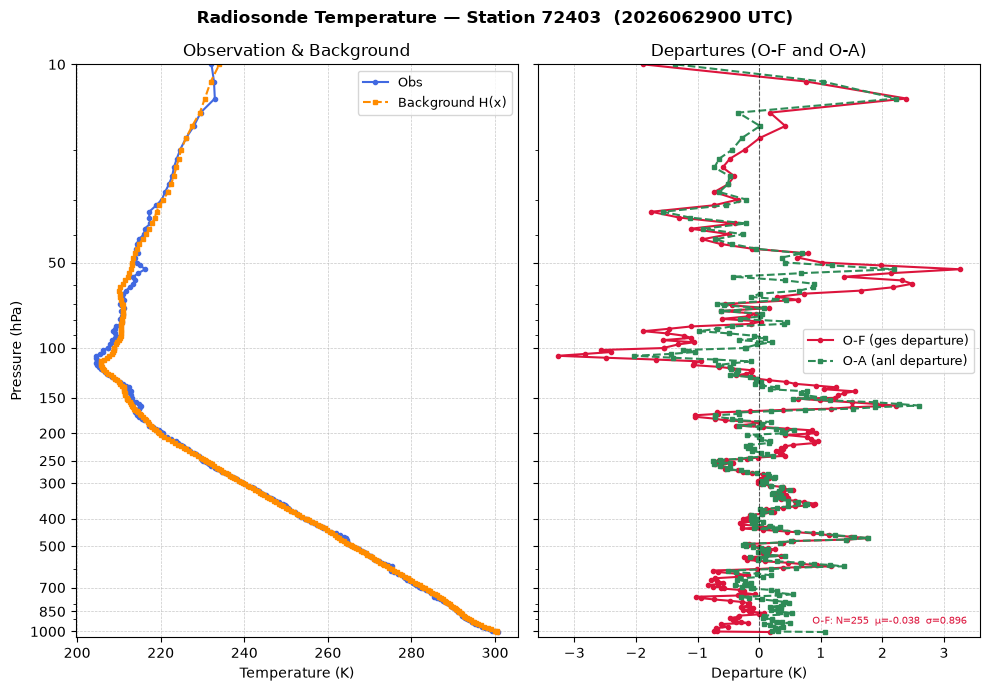

In [8]:
if df_t_ges.empty:
    print(
        f"No temperature data found for station '{STATION_ID}'.\n"
        "Check STATION_ID and ensure the diagnostic files are loaded."
    )
else:
    fig_t = plot_scalar_profile(
        pressure_ges = _safe_array(df_t_ges, "Pressure"),
        obs_ges      = _safe_array(df_t_ges, "observation"),
        hofx_ges     = _safe_array(df_t_ges, "hofx_adjusted"),
        omf_ges      = _safe_array(df_t_ges, "omf_adjusted"),
        pressure_anl = _safe_array(df_t_anl, "Pressure"),
        oma_anl      = _safe_array(df_t_anl, "omf_adjusted"),
        var_label    = "Temperature",
        unit         = "K",
        station_id   = STATION_ID,
        cycle_date   = CYCLE_DATE,
    )
    plt.show()

### 6.2 Specific Humidity Profile

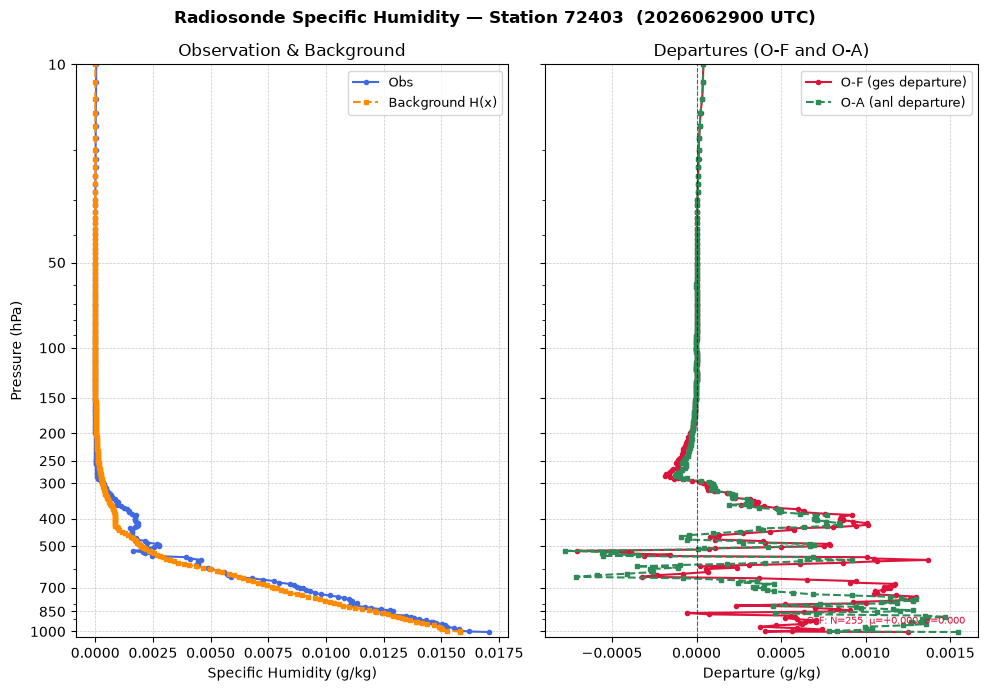

In [9]:
if df_q_ges.empty:
    print(
        f"No specific humidity data found for station '{STATION_ID}'.\n"
        "Check STATION_ID and ensure the diagnostic files are loaded."
    )
else:
    fig_q = plot_scalar_profile(
        pressure_ges = _safe_array(df_q_ges, "Pressure"),
        obs_ges      = _safe_array(df_q_ges, "observation"),
        hofx_ges     = _safe_array(df_q_ges, "hofx_adjusted"),
        omf_ges      = _safe_array(df_q_ges, "omf_adjusted"),
        pressure_anl = _safe_array(df_q_anl, "Pressure"),
        oma_anl      = _safe_array(df_q_anl, "omf_adjusted"),
        var_label    = "Specific Humidity",
        unit         = "g/kg",
        station_id   = STATION_ID,
        cycle_date   = CYCLE_DATE,
    )
    plt.show()

### 6.3 U-Wind Profile

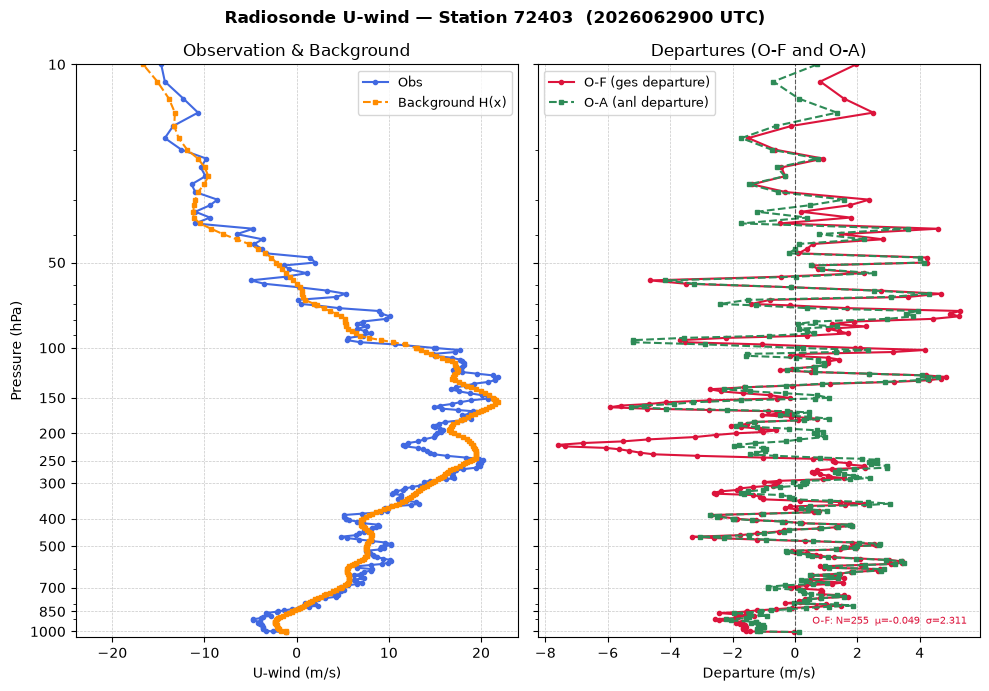

In [10]:
if df_uv_ges.empty:
    print(
        f"No wind data found for station '{STATION_ID}'.\n"
        "Check STATION_ID and ensure the diagnostic files are loaded."
    )
else:
    fig_u = plot_wind_profile(
        component    = "U",
        pressure_ges = _safe_array(df_uv_ges, "Pressure"),
        obs_ges      = _safe_array(df_uv_ges, "u_observation"),
        hofx_ges     = _safe_array(df_uv_ges, "u_hofx_adjusted"),
        omf_ges      = _safe_array(df_uv_ges, "u_omf_adjusted"),
        pressure_anl = _safe_array(df_uv_anl, "Pressure"),
        oma_anl      = _safe_array(df_uv_anl, "u_omf_adjusted"),
        station_id   = STATION_ID,
        cycle_date   = CYCLE_DATE,
    )
    plt.show()

### 6.4 V-Wind Profile

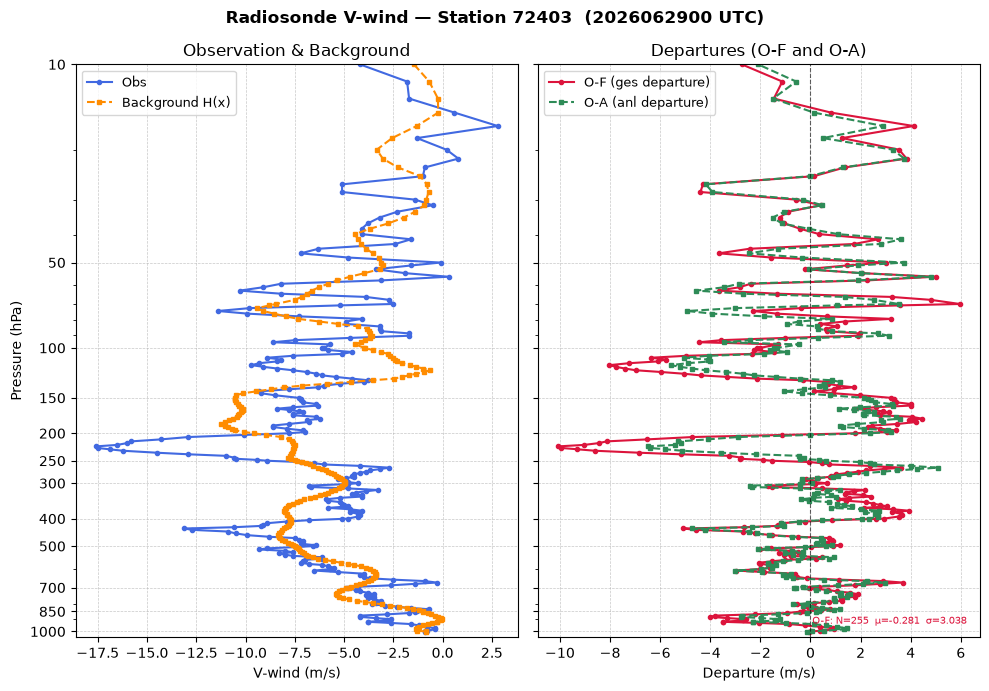

In [11]:
if df_uv_ges.empty:
    print(f"No wind data found for station '{STATION_ID}'.")
else:
    fig_v = plot_wind_profile(
        component    = "V",
        pressure_ges = _safe_array(df_uv_ges, "Pressure"),
        obs_ges      = _safe_array(df_uv_ges, "v_observation"),
        hofx_ges     = _safe_array(df_uv_ges, "v_hofx_adjusted"),
        omf_ges      = _safe_array(df_uv_ges, "v_omf_adjusted"),
        pressure_anl = _safe_array(df_uv_anl, "Pressure"),
        oma_anl      = _safe_array(df_uv_anl, "v_omf_adjusted"),
        station_id   = STATION_ID,
        cycle_date   = CYCLE_DATE,
    )
    plt.show()

## 7. Summary Statistics Table

Quick look at N, mean, and RMSE of O-F and O-A for each variable.

In [12]:
def profile_stats(
    values: np.ndarray,
    label: str,
) -> dict:
    """Compute summary statistics for a departure array.

    Parameters
    ----------
    values:
        1-D array of departure values (O-F or O-A).
    label:
        Row label string.

    Returns
    -------
    dict
        Keys: ``'Label'``, ``'N'``, ``'Mean'``, ``'Std'``, ``'RMSE'``.
    """
    if len(values) == 0:
        return {"Label": label, "N": 0, "Mean": float("nan"),
                "Std": float("nan"), "RMSE": float("nan")}
    return {
        "Label": label,
        "N":     len(values),
        "Mean":  float(np.nanmean(values)),
        "Std":   float(np.nanstd(values)),
        "RMSE":  float(np.sqrt(np.nanmean(values ** 2))),
    }


rows = [
    profile_stats(_safe_array(df_t_ges,  "omf_adjusted"),    "T  O-F (K)"),
    profile_stats(_safe_array(df_t_anl,  "omf_adjusted"),    "T  O-A (K)"),
    profile_stats(_safe_array(df_q_ges,  "omf_adjusted"),    "q  O-F (g/kg)"),
    profile_stats(_safe_array(df_q_anl,  "omf_adjusted"),    "q  O-A (g/kg)"),
    profile_stats(_safe_array(df_uv_ges, "u_omf_adjusted"),  "U  O-F (m/s)"),
    profile_stats(_safe_array(df_uv_anl, "u_omf_adjusted"),  "U  O-A (m/s)"),
    profile_stats(_safe_array(df_uv_ges, "v_omf_adjusted"),  "V  O-F (m/s)"),
    profile_stats(_safe_array(df_uv_anl, "v_omf_adjusted"),  "V  O-A (m/s)"),
]

stats_df = pd.DataFrame(rows).set_index("Label")
stats_df["Mean"] = stats_df["Mean"].map("{:+.4f}".format)
stats_df["Std"]  = stats_df["Std"].map("{:.4f}".format)
stats_df["RMSE"] = stats_df["RMSE"].map("{:.4f}".format)
print(f"\nStation {STATION_ID}  |  {CYCLE_DATE} UTC\n")
display(stats_df)


Station 72403  |  2026062900 UTC



,N,Mean,Std,RMSE
Label,,,,
T O-F (K),255,-0.0382,0.8959,0.8967
T O-A (K),255,+0.0873,0.6226,0.6287
q O-F (g/kg),255,+0.0002,0.0004,0.0005
q O-A (g/kg),255,+0.0002,0.0004,0.0005
U O-F (m/s),255,-0.0491,2.3105,2.3110
U O-A (m/s),255,+0.2163,1.8249,1.8377
V O-F (m/s),255,-0.2815,3.0381,3.0512
V O-A (m/s),255,-0.1535,2.2878,2.2930
